## Running kinGEMs Pipeline on $E. coli$ iML1515 Model

In [ ]:

%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import cobra # type: ignore
import numpy as np # type: ignore
from datetime import datetime
import random
from cobra.io import write_sbml_model # type: ignore
import cobra as cb

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

# Import kinGEMs components
import kinGEMs
from kinGEMs.dataset import load_model, convert_to_irreversible, prepare_model_data, retrieve_sequences, map_metabolites, merge_substrate_sequences, process_merged_data_with_folds, process_kcat_predictions, assign_kcats_to_model, format_kcats_like_gpr, annotate_model_with_kcat_and_gpr
from kinGEMs.modeling.optimize import run_optimization_with_dataframe, validate_enzyme_constraints
from kinGEMs.modeling.tuning import simulated_annealing, analyze_kcat_changes
from kinGEMs.modeling.fva import flux_variability_analysis, plot_flux_variability, plot_cumulative_fvi_distribution


2025-06-12 16:07:55.134 | INFO     | kinGEMs.config:<module>:12 - PROJ_ROOT path is: C:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2


### Set your GEM name here

In [26]:

# === Configuration ===
organism_strain_GEMname = "ecoli_iML1515" # Update this
organism = "E coli" # Update this 
run_id = f"{organism_strain_GEMname}_{datetime.today().strftime('%Y%m%d')}_{random.randint(1000, 9999)}"

# Directories
data_dir = "../data"
raw_data_dir = os.path.join(data_dir, "raw")
interim_data_dir = os.path.join(data_dir, "interim")
interim_data_dir_spec = os.path.join(interim_data_dir, f"{organism_strain_GEMname}")
processed_data_dir = os.path.join(data_dir, "processed")
processed_data_dir_spec = os.path.join(processed_data_dir, f"{organism_strain_GEMname}")
CPIPred_data_dir = os.path.join(interim_data_dir, "CPI-Pred predictions")
results_dir = os.path.join(os.getcwd(), "results")
tuning_results_dir = os.path.join(results_dir, "tuning_results", run_id)
os.makedirs(tuning_results_dir, exist_ok=True)

# Input files
model_path = os.path.join(raw_data_dir, "iML1515_GEM.xml") # Update this
predictions_csv_path = os.path.join(CPIPred_data_dir, f"X06A_kinGEMs_{organism_strain_GEMname}_predictions.csv")

# Output files
substrates_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_substrates.csv")
sequences_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_sequences.csv")
merged_data_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_merged_data.csv")
processed_data_output = os.path.join(processed_data_dir_spec, f"{organism_strain_GEMname}_processed_data.csv")

# Simulation parameters
biomass_reaction = 'BIOMASS_Ec_iML1515_WT_75p37M' # Update this
enzyme_upper_bound = 0.15


### Step 1: Preparing and processing model data

In [ ]:

print("=== Step 1: Preparing model data ===")
irrev_model, substrate_df, sequences_df = prepare_model_data(
    model_path=model_path,
    substrates_output=substrates_output,
    sequences_output=sequences_output,
    organism=organism
)


=== Step 1: Preparing model data ===
Loaded model with 2712 reactions and 1877 metabolites
Extracted 5247 substrate-reaction pairs


c:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2\kinGEMs\dataset.py:240: DtypeWarning: Columns (4,10) have mixed types. Specify dtype option on import or set low_memory=False.
  SEED_comps = pd.read_csv(SEED_COMPOUNDS, sep='\t')
2025-06-12 16:09:57,125 - kinGEMs.dataset - INFO - There are 1738 substrates in the GEM.
2025-06-12 16:09:57,157 - kinGEMs.dataset - INFO - -----------------------------
2025-06-12 16:09:57,157 - kinGEMs.dataset - INFO - Mapping substrate: ala__D_c
2025-06-12 16:09:57,189 - kinGEMs.dataset - INFO - BiGG Name: D-Alanine
2025-06-12 16:09:57,229 - kinGEMs.dataset - INFO - SMILES found in SEED: C[C@@H]([NH3+])C(=O)[O-]
2025-06-12 16:09:57,230 - kinGEMs.dataset - INFO - -----------------------------
2025-06-12 16:09:57,230 - kinGEMs.dataset - INFO - Mapping substrate: pydx5p_c
2025-06-12 16:09:57,258 - kinGEMs.dataset - INFO - BiGG Name: Pyridoxal 5'-phosphate
2025-06-12 16:09:57,294 - kinGEMs.dataset - INFO - SMILES found in MetaNetX: Cc1ncc(COP(=O)([O-])[O-])c(C

Mapped metabolites to SMILES (4785 found)


2025-06-12 16:17:56,026 - root - WARNING - No sequence found for gene s0001


Retrieved 1515 protein sequences


### Step 2: Merging substrate and sequence data

In [5]:

print("=== Step 2: Merging substrate and sequence data ===")

# substrate_df = pd.read_csv(substrates_output)
# sequences_df = pd.read_csv(sequences_output)
# model = load_model(model_path)
# irrev_model = convert_to_irreversible(model)

merged_data = merge_substrate_sequences(
    substrate_df=substrate_df,
    sequences_df=sequences_df,
    model=irrev_model,
    output_path=merged_data_output
)


=== Step 2: Merging substrate and sequence data ===


### Step 3: Processing CPI-Pred kcat values

In [6]:

print("=== Step 3: Processing CPI-Pred kcat values & annotating model ===")
processed_data = process_kcat_predictions(
    merged_df=merged_data,
    predictions_csv_path=predictions_csv_path,
    output_path=processed_data_output
)

irrev_model = annotate_model_with_kcat_and_gpr(
    model=irrev_model,
    df=processed_data
)


=== Step 3: Processing CPI-Pred kcat values & annotating model ===


## Step 4: Optimization (FBA Sanity Check + kinGEMs)

make sure code below works first

In [22]:
# 1) Load your COBRApy model
model = irrev_model
# Or if you have a JSON:
# model = cobra.io.load_json_model("path/to/your_model.json")

# 2) Extract S, bounds, and objective coefficients
#    S will be shape (m metabolites × n reactions)
S = create_stoichiometric_matrix(model)  

metabolites = list(model.metabolites)
reactions   = list(model.reactions)
m, n = S.shape

lb = np.array([rxn.lower_bound for rxn in reactions])
ub = np.array([rxn.upper_bound for rxn in reactions])
c  = np.array([rxn.objective_coefficient for rxn in reactions])

# 3) Build the Pyomo model
pyomo_model = ConcreteModel()
pyomo_model.I = Set(initialize=range(m))  # metabolite indices
pyomo_model.J = Set(initialize=range(n))  # reaction indices

# flux variables v[j] with the same bounds
def v_bounds(mod, j):
    return (float(lb[j]), float(ub[j]))
pyomo_model.v = Var(pyomo_model.J, domain=Reals, bounds=v_bounds)

# mass‐balance constraints: for each metabolite i, sum_j S[i,j]*v[j] == 0
def mass_balance_rule(mod, i):
    return sum(S[i, j] * mod.v[j] for j in mod.J) == 0
pyomo_model.mass_balance = Constraint(pyomo_model.I, rule=mass_balance_rule)

# objective: maximize cᵀ v
pyomo_model.obj = Objective(
    expr = sum(c[j] * pyomo_model.v[j] for j in pyomo_model.J),
    sense = maximize
)

# 4) Solve it with GLPK (or another LP solver you've installed)
solver = SolverFactory('glpk')
result = solver.solve(pyomo_model, tee=False)

# 5) Extract Pyomo solution
pyomo_fluxes = np.array([value(pyomo_model.v[j]) for j in range(n)])
pyomo_obj     = value(pyomo_model.obj)

# 6) Solve with COBRApy’s built-in optimizer for comparison
cobra_solution = model.optimize()
cobra_fluxes   = np.array([cobra_solution.fluxes[rxn.id] for rxn in reactions])
cobra_obj      = cobra_solution.objective_value

# 7) Verify they match
print(f" COBRA optimize() objective: {cobra_obj:.6g}")
print(f"   Pyomo objective:        {pyomo_obj:.6g}")
print(" Max |flux_pyomo – flux_cobra| =", np.max(np.abs(pyomo_fluxes - cobra_fluxes)))


 COBRA optimize() objective: 0.876997
   Pyomo objective:        0.876997
 Max |flux_pyomo – flux_cobra| = 1000.0


In [30]:
print("=== Step 4: Running optimization with kcat constraints ===")
(solution_value, df_FBA, gene_sequences_dict, _)=run_optimization_with_dataframe(
    model=irrev_model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=0.15, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True)

print("Biomass value: ", solution_value)

=== Step 4: Running optimization with kcat constraints ===
GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\Rana\AppData\Local\Temp\tmpagbhzbps.glpk.raw --wglp C:\Users\Rana\AppData\Local\Temp\tmpqhf9dlzn.glpk.glp
 --cpxlp C:\Users\Rana\AppData\Local\Temp\tmpbx0jjv1h.pyomo.lp
Reading problem data from 'C:\Users\Rana\AppData\Local\Temp\tmpbx0jjv1h.pyomo.lp'...
6036 rows, 4229 columns, 25103 non-zeros
47450 lines were read
Writing problem data to 'C:\Users\Rana\AppData\Local\Temp\tmpqhf9dlzn.glpk.glp'...
42244 lines were written
GLPK Simplex Optimizer 5.0
6036 rows, 4229 columns, 25103 non-zeros
Preprocessing...
4123 rows, 3278 columns, 17924 non-zeros
Scaling...
 A: min|aij| =  3.202e-07  max|aij| =  3.123e+06  ratio =  9.755e+12
GM: min|aij| =  1.276e-02  max|aij| =  7.835e+01  ratio =  6.139e+03
EQ: min|aij| =  1.629e-04  max|aij| =  1.000e+00  ratio =  6.139e+03
Constructing initial basis...
Size of triangular part is 4055
      0: obj =  -

In [31]:
## Run optimization 10 times with FBA initialization to check for robustness 
# prepare a list to hold the biomass solutions
biomass_values = []

for i in range(10):
    print(f"=== Iteration {i+1} ===")
    solution_value, df_FBA, gene_sequences_dict, _ = run_optimization_with_dataframe(
        model=irrev_model, 
        processed_df=processed_data, 
        objective_reaction=biomass_reaction, 
        enzyme_upper_bound=enzyme_upper_bound, 
        enzyme_ratio=True, 
        maximization=True, 
        multi_enzyme_off=False, 
        isoenzymes_off=False, 
        promiscuous_off=False, 
        complexes_off=False,
        output_dir=None, 
        save_results=False,
        print_reaction_conditions=True
    )

    print(f"Biomass value: {solution_value:.4f}\n")
    biomass_values.append(solution_value)

# once done, print the summary list
print("All biomass values over 10 runs:")
for idx, val in enumerate(biomass_values, 1):
    print(f" Run {idx}: {val:.4f}")


=== Iteration 1 ===
GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\Rana\AppData\Local\Temp\tmp0yjd4_tf.glpk.raw --wglp C:\Users\Rana\AppData\Local\Temp\tmpv0h2e0zf.glpk.glp
 --cpxlp C:\Users\Rana\AppData\Local\Temp\tmpnslrepk1.pyomo.lp
Reading problem data from 'C:\Users\Rana\AppData\Local\Temp\tmpnslrepk1.pyomo.lp'...
6036 rows, 4229 columns, 25103 non-zeros
47450 lines were read
Writing problem data to 'C:\Users\Rana\AppData\Local\Temp\tmpv0h2e0zf.glpk.glp'...
42244 lines were written
GLPK Simplex Optimizer 5.0
6036 rows, 4229 columns, 25103 non-zeros
Preprocessing...
4123 rows, 3278 columns, 17924 non-zeros
Scaling...
 A: min|aij| =  3.202e-07  max|aij| =  3.123e+06  ratio =  9.755e+12
GM: min|aij| =  1.276e-02  max|aij| =  7.835e+01  ratio =  6.139e+03
EQ: min|aij| =  1.629e-04  max|aij| =  1.000e+00  ratio =  6.139e+03
Constructing initial basis...
Size of triangular part is 4055
      0: obj =  -0.000000000e+00 inf =   3.025e+04 (281)

In [ ]:
multi_enzyme_off = False

# LISTS used in rule_kcat
single_enzyme = []
multiple_enzyme = []
no_enzyme = []

# CHECKPOINTS for rule_kcat
single_enzyme_pass = [] 
multiple_enzyme_pass = []
no_enzyme_pass = []

# CHECKPOINTS for evaluate_gpr & rule_promiscuous
isoenzymes_pass = []
enzyme_complexes_pass = [] 
promiscuous_pass = []

# DICTIONARIES for flux bounds, kcats, replaced GPRs and S matrix 
S_mat = {}
lower_bounds = {}
upper_bounds = {}
kcat = {}
gpr = {}
reaction_gene_tuple = set()

for reaction in irrev_model.reactions:
    # Flux bounds dict
    lower_bounds[reaction.id] = reaction.lower_bound
    upper_bounds[reaction.id] = reaction.upper_bound

    # print(f"Reaction {reaction} has lower bound {reaction.lower_bound} and upper bound {reaction.upper_bound}")
    
    # kcat dict - FIXED: Convert kcat from 1/s to 1/hr
    kcat_value = (reaction.annotation).get('kcat')
    if kcat_value is not None:
        if isinstance(kcat_value, list):  # For multiple kcat
            # Convert each kcat from 1/s to 1/hr by multiplying by 3600
            kcat_list = [float(value) * 3600 for value in kcat_value]
            if kcat_list:
                kcat[reaction.id] = kcat_list
        else:  # For single kcats
            try: 
                # Convert kcat from 1/s to 1/hr by multiplying by 3600
                single_kcat = float(kcat_value) * 3600
                kcat[reaction.id] = [single_kcat]
            except ValueError:
                pass
    
    # GPR with replaced kcats dict
    gpr_value = (reaction.annotation).get('gpr_replaced')
    if gpr_value is not None:
        gpr[reaction.id] = gpr_value
        
    # Reaction ID - Gene ID tuple    
    for gene in reaction.genes:
        reaction_gene_tuple.add((reaction.id, gene.id))
    
    # S matrix dict
    for met in irrev_model.metabolites:
        try:
            reaction.get_coefficient(met.id)
        except:  # noqa: E722
            pass
        else:
            S_mat[met.id, reaction.id] = reaction.get_coefficient(met.id)


for reaction in irrev_model.reactions:
    gpr_tag = (reaction.annotation).get('gpr')
    # Get the reaction object from the model
    enzymes_for_reaction = [i for j, i in reaction_gene_tuple if j == reaction.id]
    
    if multi_enzyme_off:
        if gpr_tag == '1' or gpr_tag == 'AND/OR':
            single_enzyme.extend([(reaction.id, i) for i in enzymes_for_reaction])
        else: 
            no_enzyme.append(reaction.id)
    else:
        if gpr_tag == '1':
            single_enzyme.extend([(reaction.id, i) for i in enzymes_for_reaction])
        elif gpr_tag == 'AND/OR':
            multiple_enzyme.extend([(reaction.id, i) for i in enzymes_for_reaction])
        else:
            no_enzyme.append(reaction.id)

### Step 5: Simulated Annealing

=== Step 5: Running simulated annealing ===
GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\Rana\AppData\Local\Temp\tmpweuo16at.glpk.raw --wglp C:\Users\Rana\AppData\Local\Temp\tmpmopbhxjq.glpk.glp
 --cpxlp C:\Users\Rana\AppData\Local\Temp\tmpzaawo7ls.pyomo.lp
Reading problem data from 'C:\Users\Rana\AppData\Local\Temp\tmpzaawo7ls.pyomo.lp'...
6036 rows, 4229 columns, 25103 non-zeros
47450 lines were read
Writing problem data to 'C:\Users\Rana\AppData\Local\Temp\tmpmopbhxjq.glpk.glp'...
42244 lines were written
GLPK Simplex Optimizer 5.0
6036 rows, 4229 columns, 25103 non-zeros
Preprocessing...
4123 rows, 3278 columns, 17924 non-zeros
Scaling...
 A: min|aij| =  3.202e-07  max|aij| =  3.123e+06  ratio =  9.755e+12
GM: min|aij| =  1.276e-02  max|aij| =  7.835e+01  ratio =  6.139e+03
EQ: min|aij| =  1.629e-04  max|aij| =  1.000e+00  ratio =  6.139e+03
Constructing initial basis...
Size of triangular part is 4055
      0: obj =  -0.000000000e+00

2025-06-13 14:03:26,416 - gurobipy - INFO - Read LP format model from file C:\Users\Rana\AppData\Local\Temp\tmpp138ez34.lp


Reading time = 0.03 seconds


2025-06-13 14:03:26,418 - gurobipy - INFO - Reading time = 0.03 seconds


: 1877 rows, 5424 columns, 21150 nonzeros


...

Reading time = 0.02 seconds


2025-06-13 15:03:30,190 - gurobipy - INFO - Reading time = 0.02 seconds


: 1877 rows, 5424 columns, 21150 nonzeros


2025-06-13 15:03:30,191 - gurobipy - INFO - : 1877 rows, 5424 columns, 21150 nonzeros


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write C:\Users\Rana\AppData\Local\Temp\tmpwcxkhk90.glpk.raw --wglp C:\Users\Rana\AppData\Local\Temp\tmp_awkqduo.glpk.glp
 --cpxlp C:\Users\Rana\AppData\Local\Temp\tmp7j2hhf_k.pyomo.lp
Reading problem data from 'C:\Users\Rana\AppData\Local\Temp\tmp7j2hhf_k.pyomo.lp'...
6027 rows, 4229 columns, 25072 non-zeros
47392 lines were read
Writing problem data to 'C:\Users\Rana\AppData\Local\Temp\tmp_awkqduo.glpk.glp'...
42195 lines were written
GLPK Simplex Optimizer 5.0
6027 rows, 4229 columns, 25072 non-zeros
Preprocessing...
4114 rows, 3278 columns, 17893 non-zeros
Scaling...
 A: min|aij| =  3.202e-07  max|aij| =  3.123e+06  ratio =  9.755e+12
GM: min|aij| =  1.276e-02  max|aij| =  7.835e+01  ratio =  6.139e+03
EQ: min|aij| =  1.629e-04  max|aij| =  1.000e+00  ratio =  6.139e+03
Constructing initial basis...
Size of triangular part is 4046
      0: obj =  -0.000000000e+00 inf =   2.951e+04 (281)
Perturbing LP to av

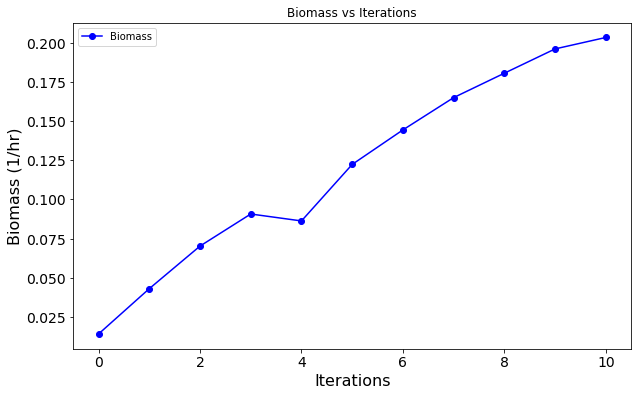

In [32]:

print("=== Step 5: Running simulated annealing ===")
temperature = 1.0
cooling_rate = 0.95
min_temperature = 0.01
max_iterations = 100
max_unchanged_iterations = 10
change_threshold = 0.001
biomass_goal = 0.5

kcat_dict, top_targets, df_new, iterations, biomasses, df_FBA = simulated_annealing(
    model=irrev_model,
    processed_data=processed_data,
    biomass_reaction=biomass_reaction,
    objective_value=biomass_goal,
    gene_sequences_dict=gene_sequences_dict,      # ← new
    output_dir=tuning_results_dir,
    enzyme_fraction=enzyme_upper_bound,
    temperature=temperature,
    cooling_rate=cooling_rate,
    min_temperature=min_temperature,
    max_iterations=max_iterations,
    max_unchanged_iterations=max_unchanged_iterations,
    change_threshold=change_threshold
)

print(f"Final biomass: {biomasses[-1]:.4f}")
print(f"Improvement: {(biomasses[-1] - biomasses[0]) / biomasses[0] * 100:.1f}%")
print("Top‐25 enzymes by mass contribution:")
print(top_targets[['Reactions','Single_gene','enzyme_mass']])


### Step 6: FVA 

In [ ]:

print("=== Step 6: Running Flux Variability Analysis ===")
fva_results_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_results.csv")
fva_plot_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_flux_range_plot.png")
fva_cumulative_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_cumulative_plot.png")

fva_results, _, _ = flux_variability_analysis(
    model=irrev_model,
    processed_df=df_new,
    biomass_reaction=biomass_reaction,
    output_file=fva_results_path,
    enzyme_upper_bound=enzyme_upper_bound
)

# Plot standard FVA range
fig = plot_flux_variability(fva_results, output_file=fva_plot_path)

# Plot cumulative distribution
plot_cumulative_fvi_distribution(
    dfs=[fva_results],
    labels=[organism_strain_GEMname],
    output_file=fva_cumulative_path
)


### Step 7: Save Final Model

In [ ]:
# Define output path for final GEM
model_output_dir = os.path.join("models")
os.makedirs(model_output_dir, exist_ok=True)
model_output_path = os.path.join(model_output_dir, f"{run_id}.xml")

# After simulated annealing
model_with_kcats = assign_kcats_to_model(irrev_model, df_new)

# Preview:
format_kcats_like_gpr(model_with_kcats.reactions.get_by_id("PGI"))


# Save the final irreversible model
write_sbml_model(model_with_kcats, model_output_path)

print(f"Final GEM saved to: {model_output_path}")